# Growth-rate volatility vs size — fixed $\mu$, high-$\sigma$ sweep

Reproduces the **Moran–Secchi–Bouchaud** size–volatility relation, holding the mean interaction
$\mu=0.2$ **fixed** and sweeping the disorder $\sigma$ from the prior baseline ($\sigma=0.2$) up to
strong disorder ($\sigma=4.0$). For each $\sigma$ we plot per-firm growth-rate volatility
$\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$ against time-average relative size $\bar S_i$.

**What actually happens (the finding).** At $\mu=0.2$ the system is **subcritical only for
$\sigma\lesssim 0.6$** (total mass $M$ converges, physical time runs ~700 yr). For $\sigma\gtrsim 0.6$
it goes **supercritical**: $M$ diverges (overflows $\sim10^{308}$), the integrator stops early, and
physical time reaches only ~0.5–2 yr — so the physical-year MSB measurement **breaks down**. We keep
the physical-time clock and *show* this breakdown: subcritical $\sigma$ get a valid V-curve;
supercritical $\sigma$ are flagged (dashed/"invalid") and quantified in the summary.

**Caveats.**
- $\mu_c$ drifts with $\sigma$; $\mu=0.2$ is a held subcritical reference, not critical at every $\sigma$.
- Relative size $S=N\,y/\sum y$ is built from the **shape** $y$, never $x=yM$, so it cannot overflow.
- A run is **subcritical** iff the solver reaches $\tau_{\max}$ (`sol.status==0`); otherwise $M$
  diverged (supercritical). Failed integrations (`sol.t.size<3`) are dropped and counted.
- Physical-time volatility mixes transient and any persistent dynamics; this is descriptive and cannot
  attribute cause.

In [1]:
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # spawn re-imports the kernel and breaks the pool

import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.integrate import solve_ivp

import glv
glv.apply_style()

N         = 1000                                  # species / firms
C         = 5                                     # mean degree
MU        = 0.2                                   # FIXED mean interaction (subcritical at low sigma)
SIGMAS    = [0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]   # disorder sweep: baseline -> strong
n_runs    = 10                                    # graph realizations per sigma (pooled)
tau_max   = 1e6                                   # rescaled-time horizon
n_years   = 100                                   # yearly resample grid (physical time)
FLOOR     = 1e-3                                  # live-firm threshold for binning
MIN_FIRMS = 100                                   # min firms to draw a curve for a sigma/regime
n_workers = min(8, (mp.cpu_count() or 2))
RES = "volatility_sigma_sweep_results.npz"
print(f"mu={MU} fixed | sigma grid={SIGMAS} | N={N} x n_runs={n_runs} per sigma | workers={n_workers}")

mu=0.2 fixed | sigma grid=[0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0] | N=1000 x n_runs=10 per sigma | workers=8


In [2]:
# Degree law: exponential, kept inline (project convention: no library wrapper)
def exponential_degrees(C, rng):
    return np.maximum(rng.exponential(C, N).astype(int), 1)

def make_even(deg):
    deg = np.asarray(deg).copy()
    if deg.sum() % 2:
        deg[0] += 1
    return deg

In [3]:
# Measurement: one float64 integration. Build the rescaled state [y (simplex), M, t]
# internally; relative size S = N*y/sum(y) comes from the SHAPE y, so x = y*M is never
# formed and the diverging M at high sigma cannot overflow.
#   reached == True  <=> solver reached tau_max (M finite) => SUBcritical, valid physical time
#   reached == False <=> integration stopped early (M diverged) => SUPERcritical breakdown
def run_one(W, x0):
    state0 = np.concatenate([x0 / x0.sum(), [x0.sum()], [0.0]])
    sol = solve_ivp(glv.rescaled_glv_sparse, (0.0, tau_max), state0, args=(N, W),
                    method="RK45", max_step=1e2)
    if sol.t.size < 3:
        return None
    reached = bool(sol.status == 0)
    y = sol.y[:N, :]
    t_phys = sol.y[N + 1, :]
    t_final = t_phys[-1]
    if not np.isfinite(t_final) or t_final <= t_phys[0]:
        return None
    dt = (t_final - t_phys[0]) / n_years
    t_years = np.arange(t_phys[0], t_final, dt)
    y_yearly = np.array([np.interp(t_years, t_phys, y[k]) for k in range(N)])
    totals = y_yearly.sum(axis=0, keepdims=True)
    totals = np.where(totals > 0, totals, np.nan)
    S = N * y_yearly / totals                         # = N x_i / sum_j x_j, M cancels
    log_S = np.log(np.maximum(S, 1e-15))
    g = np.diff(log_S, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    sigma_i = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    return S.mean(axis=1), sigma_i, reached, float(t_final)

def _job(args):
    sigma, seed = args
    rng = np.random.default_rng(seed)
    W = glv.generate_matrix(make_even(exponential_degrees(C, rng)), C, mu=MU, sigma=sigma)
    return sigma, run_one(W, rng.uniform(0.1, 1.0, N))

def vbin(x, y, nb=22):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]),
            np.array([np.median(yp[p]) for p in parts]))

def two_slopes(x, y):
    bx, by = vbin(x, y)
    j = int(np.argmin(by))
    if j < 1 or j > len(bx) - 2:                      # no interior V-min -> single fit
        s = np.polyfit(np.log10(bx), np.log10(by), 1)[0]
        return bx[j], s, s
    lo = np.polyfit(np.log10(bx[:j + 1]), np.log10(by[:j + 1]), 1)[0]
    hi = np.polyfit(np.log10(bx[j:]), np.log10(by[j:]), 1)[0]
    return bx[j], lo, hi

In [4]:
# Sweep over (sigma, run); pool per-firm (avg_size, volatility, reached). Cache to .npz.
# Failed integrations are dropped and COUNTED; sub/supercritical runs counted separately.
if os.path.exists(RES):
    d = np.load(RES)
    sigmas, avg_all, sig_all = d["sigmas"], d["avg_all"], d["sig_all"]
    sig_of, reached_of = d["sig_of"], d["reached_of"]
    dropped, n_sub, n_super, tfin_med = d["dropped"], d["n_sub"], d["n_super"], d["tfin_med"]
    print(f"loaded cache {RES}")
else:
    jobs = [(s, 1000 + 100 * si + r) for si, s in enumerate(SIGMAS) for r in range(n_runs)]
    s_index = {s: i for i, s in enumerate(SIGMAS)}
    avg_list, sig_list, of_list, reach_list = [], [], [], []
    dropped = np.zeros(len(SIGMAS), int)
    n_sub = np.zeros(len(SIGMAS), int)
    n_super = np.zeros(len(SIGMAS), int)
    tfin = [[] for _ in SIGMAS]
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_job, j) for j in jobs]
        for done, fut in enumerate(as_completed(futs), 1):
            sigma, res = fut.result()
            i = s_index[sigma]
            if res is None:
                dropped[i] += 1; tag = "drop"
            else:
                a, s, reached, tf = res
                avg_list.append(a); sig_list.append(s)
                of_list.append(np.full(a.size, sigma))
                reach_list.append(np.full(a.size, reached))
                tfin[i].append(tf)
                if reached: n_sub[i] += 1
                else:       n_super[i] += 1
                tag = "ok(sub)" if reached else "ok(SUPER)"
            print(f"  [{done}/{len(jobs)}] sigma={sigma}: {tag}")
    sigmas = np.array(SIGMAS, float)
    avg_all = np.concatenate(avg_list)
    sig_all = np.concatenate(sig_list)
    sig_of = np.concatenate(of_list)
    reached_of = np.concatenate(reach_list)
    tfin_med = np.array([np.median(t) if t else np.nan for t in tfin])
    np.savez(RES, sigmas=sigmas, avg_all=avg_all, sig_all=sig_all, sig_of=sig_of,
             reached_of=reached_of, dropped=dropped, n_sub=n_sub, n_super=n_super,
             tfin_med=tfin_med)
    print(f"saved {RES}")

print("\nper-sigma report (sub=subcritical/valid, SUPER=supercritical/M diverged):")
for i, s in enumerate(sigmas):
    mm = (sig_of == s) & reached_of
    coll = float(np.mean(avg_all[mm] < FLOOR)) if mm.any() else float("nan")
    print(f"  sigma={s:4.2f}: sub={int(n_sub[i])} SUPER={int(n_super[i])} dropped={int(dropped[i])} "
          f"| median t_phys={tfin_med[i]:9.3g} yr | collapsed(<{FLOOR:g})={100*coll:5.1f}%")

  [1/70] sigma=0.2: ok(sub)
  [2/70] sigma=0.2: ok(sub)
  [3/70] sigma=0.2: ok(sub)
  [4/70] sigma=0.2: ok(sub)
  [5/70] sigma=0.2: ok(sub)
  [6/70] sigma=0.2: ok(sub)
  [7/70] sigma=0.2: ok(sub)
  [8/70] sigma=0.2: ok(sub)


/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)


  [9/70] sigma=0.5: ok(SUPER)


  [10/70] sigma=0.2: ok(sub)
  [11/70] sigma=0.2: ok(sub)
  [12/70] sigma=0.5: ok(sub)
  [13/70] sigma=0.5: ok(sub)
  [14/70] sigma=0.5: ok(sub)
  [15/70] sigma=0.5: ok(sub)


/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)


...

/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:63: RuntimeWarning: overflow encountered in multiply
  dy = np.dot(K[:s].T, a[:s]) * h


  [53/70] sigma=3.0: ok(SUPER)
  [54/70] sigma=3.0: ok(SUPER)
  [55/70] sigma=3.0: ok(SUPER)
  [56/70] sigma=3.0: ok(SUPER)
  [57/70] sigma=3.0: ok(SUPER)
  [58/70] sigma=4.0: ok(SUPER)
  [59/70] sigma=3.0: ok(SUPER)
  [60/70] sigma=4.0: ok(SUPER)
  [61/70] sigma=3.0: ok(SUPER)
  [62/70] sigma=4.0: ok(SUPER)
  [63/70] sigma=4.0: ok(SUPER)
  [64/70] sigma=4.0: ok(SUPER)
  [65/70] sigma=4.0: ok(SUPER)


  [66/70] sigma=4.0: ok(SUPER)
  [67/70] sigma=4.0: ok(SUPER)
  [68/70] sigma=4.0: ok(SUPER)
  [69/70] sigma=4.0: ok(SUPER)


/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)


  [70/70] sigma=0.5: ok(SUPER)
saved volatility_sigma_sweep_results.npz

per-sigma report (sub=subcritical/valid, SUPER=supercritical/M diverged):
  sigma=0.20: sub=10 SUPER=0 dropped=0 | median t_phys=      752 yr | collapsed(<0.001)=  0.0%
  sigma=0.50: sub=7 SUPER=3 dropped=0 | median t_phys=      676 yr | collapsed(<0.001)=  0.0%
  sigma=1.00: sub=0 SUPER=10 dropped=0 | median t_phys=     1.24 yr | collapsed(<0.001)=  nan%
  sigma=1.50: sub=0 SUPER=10 dropped=0 | median t_phys=    0.704 yr | collapsed(<0.001)=  nan%
  sigma=2.00: sub=0 SUPER=10 dropped=0 | median t_phys=    0.521 yr | collapsed(<0.001)=  nan%
  sigma=3.00: sub=0 SUPER=10 dropped=0 | median t_phys=    0.332 yr | collapsed(<0.001)=  nan%
  sigma=4.00: sub=0 SUPER=10 dropped=0 | median t_phys=    0.236 yr | collapsed(<0.001)=  nan%


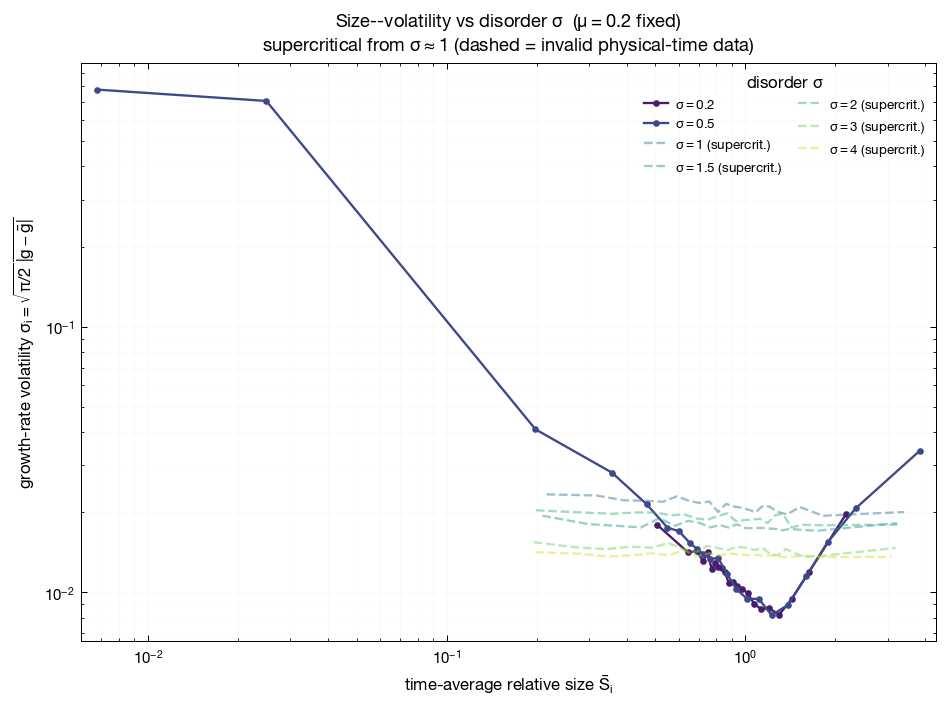

In [5]:
# Headline: size-volatility V at each sigma. Solid = subcritical (valid physical-time);
# dashed/faded = supercritical (M diverged -> physical-time data invalid, shown to expose breakdown).
fig, ax = plt.subplots(figsize=(8.0, 6))
cmap = plt.cm.viridis(np.linspace(0.08, 0.92, len(sigmas)))
onset = None
for s, col in zip(sigmas, cmap):
    base = (sig_of == s) & (avg_all > FLOOR) & (sig_all > 0) & np.isfinite(sig_all)
    sub = base & reached_of
    sup = base & ~reached_of
    if sub.sum() >= MIN_FIRMS:
        bx, by = vbin(avg_all[sub], sig_all[sub])
        ax.loglog(bx, by, "o-", ms=4, color=col, label=rf"$\sigma={s:g}$")
    else:
        if onset is None:
            onset = s
        if sup.sum() >= MIN_FIRMS:
            bx, by = vbin(avg_all[sup], sig_all[sup])
            ax.loglog(bx, by, "x--", ms=4, color=col, alpha=0.45,
                      label=rf"$\sigma={s:g}$ (supercrit.)")
title = rf"Size--volatility vs disorder $\sigma$  ($\mu={MU}$ fixed)"
if onset is not None:
    title += f"\nsupercritical from $\\sigma\\approx{onset:g}$ (dashed = invalid physical-time data)"
ax.set(xlabel=r"time-average relative size $\bar S_i$",
       ylabel=r"growth-rate volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$", title=title)
ax.grid(True, which="both", alpha=0.15)
ax.legend(title=r"disorder $\sigma$", ncol=2, framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.savefig("volatility_sigma_sweep.png", dpi=120)
plt.show()

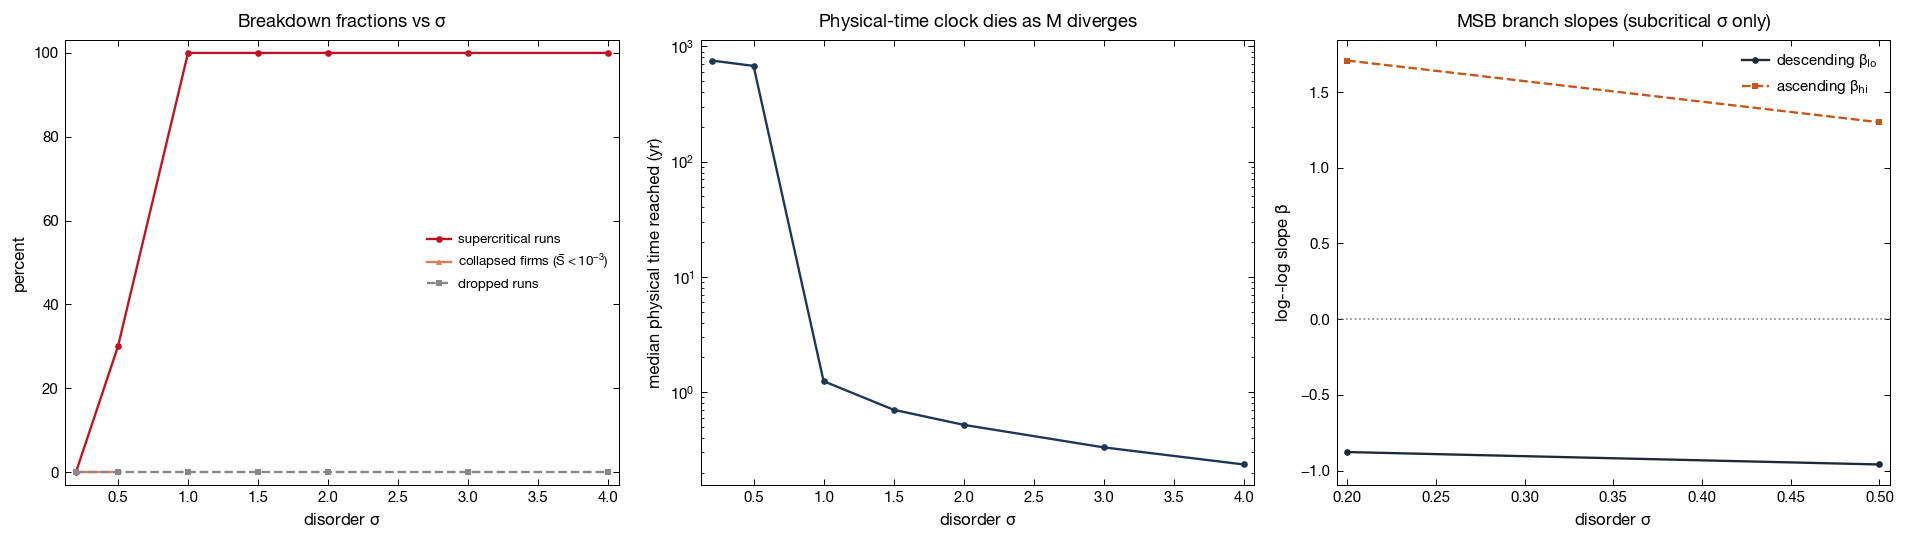

In [6]:
# Summary vs sigma: (1) breakdown fractions, (2) the physical-time clock dying, (3) MSB slopes.
super_frac = np.array([n_super[i] / max(int(n_sub[i] + n_super[i]), 1) for i in range(len(sigmas))])
drop_frac = np.array([dropped[i] / max(int(dropped[i] + n_sub[i] + n_super[i]), 1)
                      for i in range(len(sigmas))])
slopes_lo, slopes_hi, coll_frac = [], [], []
for i, s in enumerate(sigmas):
    sub = (sig_of == s) & reached_of & (avg_all > FLOOR) & (sig_all > 0) & np.isfinite(sig_all)
    if sub.sum() >= MIN_FIRMS:
        _, lo, hi = two_slopes(avg_all[sub], sig_all[sub])
        slopes_lo.append(lo); slopes_hi.append(hi)
    else:
        slopes_lo.append(np.nan); slopes_hi.append(np.nan)
    mm = (sig_of == s) & reached_of
    coll_frac.append(float(np.mean(avg_all[mm] < FLOOR)) if mm.any() else np.nan)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].plot(sigmas, 100 * super_frac, "o-", color="#c1121f", label="supercritical runs")
ax[0].plot(sigmas, 100 * np.array(coll_frac), "^-", color="#e07a5f",
           label=r"collapsed firms ($\bar S<10^{-3}$)")
ax[0].plot(sigmas, 100 * drop_frac, "s--", color="#888", label="dropped runs")
ax[0].set(xlabel=r"disorder $\sigma$", ylabel="percent", ylim=(-3, 103),
          title=r"Breakdown fractions vs $\sigma$")
ax[0].legend(fontsize=8)
ax[1].semilogy(sigmas, tfin_med, "o-", color="#1d3557")
ax[1].set(xlabel=r"disorder $\sigma$", ylabel=r"median physical time reached (yr)",
          title=r"Physical-time clock dies as $M$ diverges")
ax[2].plot(sigmas, slopes_lo, "o-", label=r"descending $\beta_{\rm lo}$")
ax[2].plot(sigmas, slopes_hi, "s--", label=r"ascending $\beta_{\rm hi}$")
ax[2].axhline(0, color="#888", lw=1, ls=":")
ax[2].set(xlabel=r"disorder $\sigma$", ylabel=r"log--log slope $\beta$",
          title=r"MSB branch slopes (subcritical $\sigma$ only)")
ax[2].legend()
plt.tight_layout()
plt.savefig("volatility_sigma_sweep_summary.png", dpi=120)
plt.show()

## Summary

_To be filled after the run (Task 4) from the per-sigma report and the two figures: the V at the
subcritical $\sigma$, the supercritical onset, how the physical-time clock and the MSB measurement
break down as $\sigma$ grows, and the collapse/dropped fractions._